# Neighborhood-Based Notifications — Stitched Pittsburgh + Allegheny County Map
### Using real administrative boundaries instead of an artificial grid

---

## The idea

The 4×4 quadrant grid was useful for testing the concept, but it cuts across real boundaries arbitrarily — half a neighborhood in one quadrant, half in another. This notebook switches to **real administrative boundaries**: Pittsburgh's 90 official neighborhoods, plus Allegheny County's municipality boundaries for everything outside the city.

## The stitching problem

We have two geojson files:
- `pgh_neighborhoods.geojson` — 90 neighborhood polygons, but **only covering the City of Pittsburgh**
- `allegheny_county_boundaries.geojson` — 130 municipality polygons covering the **whole county**, where the City of Pittsburgh is just one single polygon named `PITTSBURGH`

If we just used both as-is, the City of Pittsburgh area would be double-counted — once as a single county polygon, and again as 90 separate neighborhoods. So we **stitch** them: drop the single `PITTSBURGH` polygon from the county dataset, and use the 90 neighborhood polygons in its place. The result is one combined map with no overlaps and no gaps — finer detail inside the city, coarser detail outside it.

## Restricting to areas with smell data

Just like the quadrant notebook, we only care about areas where people are actually reporting smells. After stitching, we'll drop any neighborhood/municipality with too few smell reports to compute a meaningful threshold, and our maps will only show the area with real report density.

## What this notebook does

1. Load both boundary files and inspect them
2. Stitch them together: county municipalities (minus Pittsburgh) + 90 Pittsburgh neighborhoods
3. Assign every smell report to a neighborhood/municipality
4. Filter to only the areas with enough report density to be meaningful
5. Build pixel masks for each remaining area and compute daily pollution sums
6. Rank days independently per area, set per-area top-10% thresholds
7. Compute FP/FN rates per area
8. Map the FP/FN rates spatially, restricted to the area with real smell data

## Step 1 — Setup

In [1]:
# pip install rasterio geopandas shapely numpy pandas matplotlib

import os
import glob
import warnings
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import geometry_mask
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')
print('imports OK')

imports OK


## Step 2 — Configuration

In [2]:
# ── SETTINGS ──────────────────────────────────────────────────────────────────

FACILITY_DIRS = {
    'facility_A': '/Users/clairevlases/Desktop/mhci/create-lab/clairton',   # ← update these paths
    'facility_B': '/Users/clairevlases/Desktop/mhci/create-lab/edgar_thomson',
    'facility_C': '/Users/clairevlases/Desktop/create/irvin'
}

NEIGHBORHOODS_GEOJSON = './pgh_neighborhoods.geojson'
COUNTY_GEOJSON        = './allegheny_county_boundaries.geojson'
SMELL_REPORTS_CSV     = './smell_reports.csv'
GLOBAL_RANKINGS_CSV   = './daily_rankings.csv'

NODATA_VAL      = 0.0
MIN_SMELL_VALUE = 3       # only count smell reports rated 3-5
TOP_FRACTION    = 0.10    # top 10% of days, computed separately per area

# An area needs at least this many total smell reports across the whole year
# to be included in the FP/FN analysis. Areas below this don't have enough
# data to compute a meaningful "high smell day" threshold.
MIN_REPORTS_FOR_ANALYSIS = 100

# ──────────────────────────────────────────────────────────────────────────────
print('Config set')

Config set


## Step 3 — Load both boundary files

In [3]:
neighborhoods = gpd.read_file(NEIGHBORHOODS_GEOJSON)
county = gpd.read_file(COUNTY_GEOJSON)

print(f'Neighborhoods: {len(neighborhoods)} features')
print(f'  Sample names: {neighborhoods["hood"].head(5).tolist()}')
print()
print(f'County municipalities: {len(county)} features')
print(f'  Sample names: {county["NAME"].head(5).tolist()}')
print(f'  Types: {county["TYPE"].unique().tolist()}')

Neighborhoods: 90 features
  Sample names: ['Point Breeze North', 'Squirrel Hill North', 'Garfield', 'Bedford Dwellings', 'Knoxville']

County municipalities: 130 features
  Sample names: ['CHESWICK', 'EDGEWORTH', 'SEWICKLEY', 'SEWICKLEY HEIGHTS', 'HARMAR']
  Types: ['BOROUGH', 'TOWNSHIP', 'CITY', 'MUNICIPALI']


## Step 4 — Stitch the two maps together

The county dataset has a single polygon named `PITTSBURGH` (the whole city as one shape). We remove that one polygon and replace it with the 90 individual neighborhood polygons, which together cover the exact same area at finer detail. Every other municipality (boroughs, townships) from the county dataset stays as-is.

In [4]:
# Drop the single Pittsburgh polygon from the county dataset
county_minus_pgh = county[county['NAME'].str.upper() != 'PITTSBURGH'].copy()
print(f'County municipalities, excluding Pittsburgh: {len(county_minus_pgh)}')

# Standardize both datasets to a common schema: 'area_name', 'area_type', 'geometry'
neigh_clean = neighborhoods[['hood', 'geometry']].rename(columns={'hood': 'area_name'}).copy()
neigh_clean['area_type'] = 'neighborhood'

county_clean = county_minus_pgh[['NAME', 'geometry']].rename(columns={'NAME': 'area_name'}).copy()
county_clean['area_type'] = 'municipality'

# Stitch: stack them into one combined GeoDataFrame
stitched = pd.concat([neigh_clean, county_clean], ignore_index=True)
stitched = gpd.GeoDataFrame(stitched, geometry='geometry', crs=neighborhoods.crs)

print(f'\nStitched map: {len(stitched)} total areas')
print(f'  {(stitched["area_type"]=="neighborhood").sum()} neighborhoods (inside Pittsburgh)')
print(f'  {(stitched["area_type"]=="municipality").sum()} municipalities (rest of county)')

County municipalities, excluding Pittsburgh: 129

Stitched map: 219 total areas
  90 neighborhoods (inside Pittsburgh)
  129 municipalities (rest of county)


### Visual check — does the stitched map look complete, with no gap where Pittsburgh used to be?

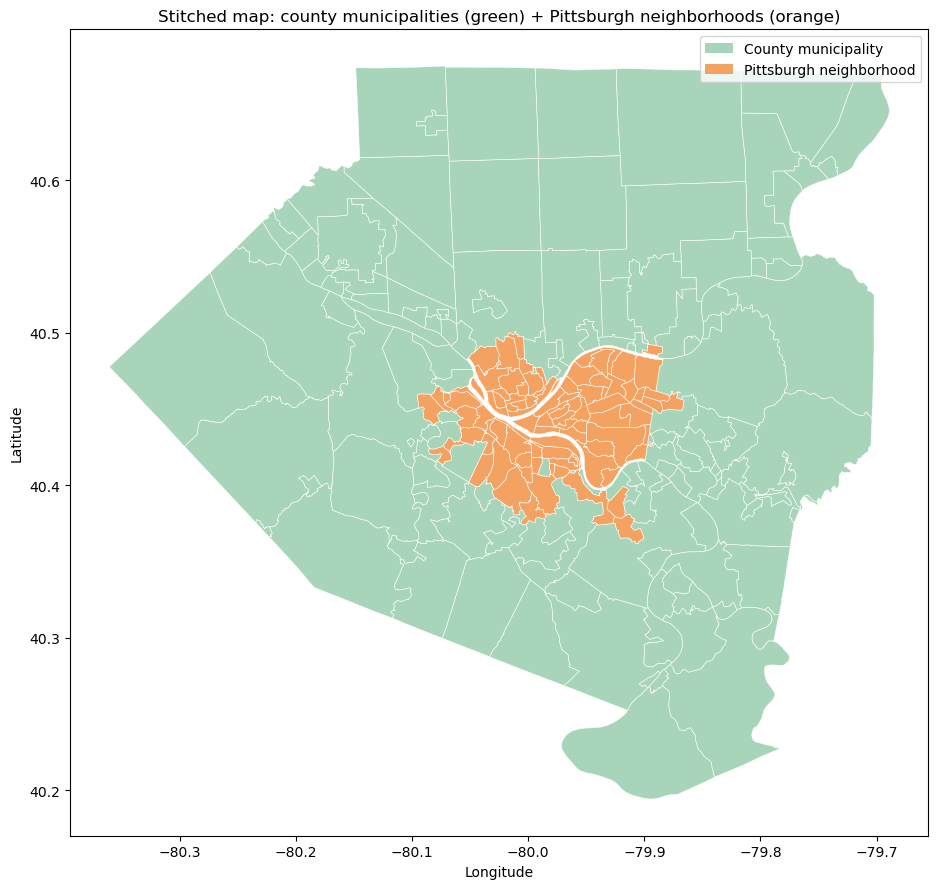

In [5]:
fig, ax = plt.subplots(figsize=(10, 9))

stitched[stitched['area_type'] == 'municipality'].plot(
    ax=ax, color='#a8d5ba', edgecolor='white', linewidth=0.4, label='Municipality'
)
stitched[stitched['area_type'] == 'neighborhood'].plot(
    ax=ax, color='#f4a261', edgecolor='white', linewidth=0.4, label='Pittsburgh neighborhood'
)

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Stitched map: county municipalities (green) + Pittsburgh neighborhoods (orange)',
             fontsize=12)
legend_patches = [
    mpatches.Patch(facecolor='#a8d5ba', label='County municipality'),
    mpatches.Patch(facecolor='#f4a261', label='Pittsburgh neighborhood'),
]
ax.legend(handles=legend_patches, fontsize=10)
plt.tight_layout()
plt.savefig('stitched_map_check.png', dpi=130, bbox_inches='tight')
plt.show()

## Step 5 — Assign smell reports to a stitched area

Spatial join: for every smell report point, find which polygon (neighborhood or municipality) contains it.

In [6]:
raw_smell = pd.read_csv(SMELL_REPORTS_CSV)
filtered_smell = raw_smell[raw_smell['smell value'] >= MIN_SMELL_VALUE].copy()
print(f'Qualifying smell reports: {len(filtered_smell):,}')

geometry = [
    Point(lon, lat) for lon, lat in
    zip(filtered_smell['skewed longitude'], filtered_smell['skewed latitude'])
]
smell_gdf = gpd.GeoDataFrame(filtered_smell, geometry=geometry, crs='EPSG:4326')

smell_with_area = gpd.sjoin(
    smell_gdf, stitched[['area_name', 'area_type', 'geometry']],
    how='left', predicate='within'
)

n_assigned = smell_with_area['area_name'].notna().sum()
n_outside  = smell_with_area['area_name'].isna().sum()
print(f'Reports assigned to an area: {n_assigned:,}')
print(f'Reports outside all areas:   {n_outside:,}')

Qualifying smell reports: 10,594
Reports assigned to an area: 10,565
Reports outside all areas:   32


## Step 6 — Filter to areas with enough report density

Areas with very few total smell reports can't produce a meaningful "high smell day" threshold (as we saw with the quadrant grid — a handful of reports gives a degenerate 75th percentile of 0). We only keep areas with at least `MIN_REPORTS_FOR_ANALYSIS` total qualifying reports across the full year.

In [19]:
# Step 6 (no minimum report filter) — keep ALL areas with at least 1 report
report_counts_by_area = smell_with_area.dropna(subset=['area_name']).groupby('area_name').size()

# No filtering — use every area that has any report data at all
areas_with_enough_data = report_counts_by_area.index.tolist()

print(f'Total areas with any reports: {len(report_counts_by_area)}')
print(f'Areas kept (no minimum applied): {len(areas_with_enough_data)}')
print()
print('Report count distribution:')
print(report_counts_by_area.describe())
print()
print('Areas with fewer than 10 reports (will likely have degenerate thresholds):')
print(report_counts_by_area[report_counts_by_area < 10].sort_values())

# Filter the stitched map down to just these areas
analysis_areas = stitched[stitched['area_name'].isin(areas_with_enough_data)].copy()
print(f'\nFiltered map: {len(analysis_areas)} areas will be used for the analysis')

Total areas with any reports: 175
Areas kept (no minimum applied): 175

Report count distribution:
count    175.000000
mean      60.371429
std      109.401266
min        1.000000
25%        5.000000
50%       15.000000
75%       62.000000
max      750.000000
dtype: float64

Areas with fewer than 10 reports (will likely have degenerate thresholds):
area_name
KENNEDY            1
MARSHALL           1
FORWARD            1
HEIDELBERG         1
EAST DEER          1
                  ..
Central Oakland    9
ROBINSON           9
Glen Hazel         9
WEST HOMESTEAD     9
East Hills         9
Length: 67, dtype: int64

Filtered map: 177 areas will be used for the analysis


### Visual check — the analysis area (only places with enough smell data)

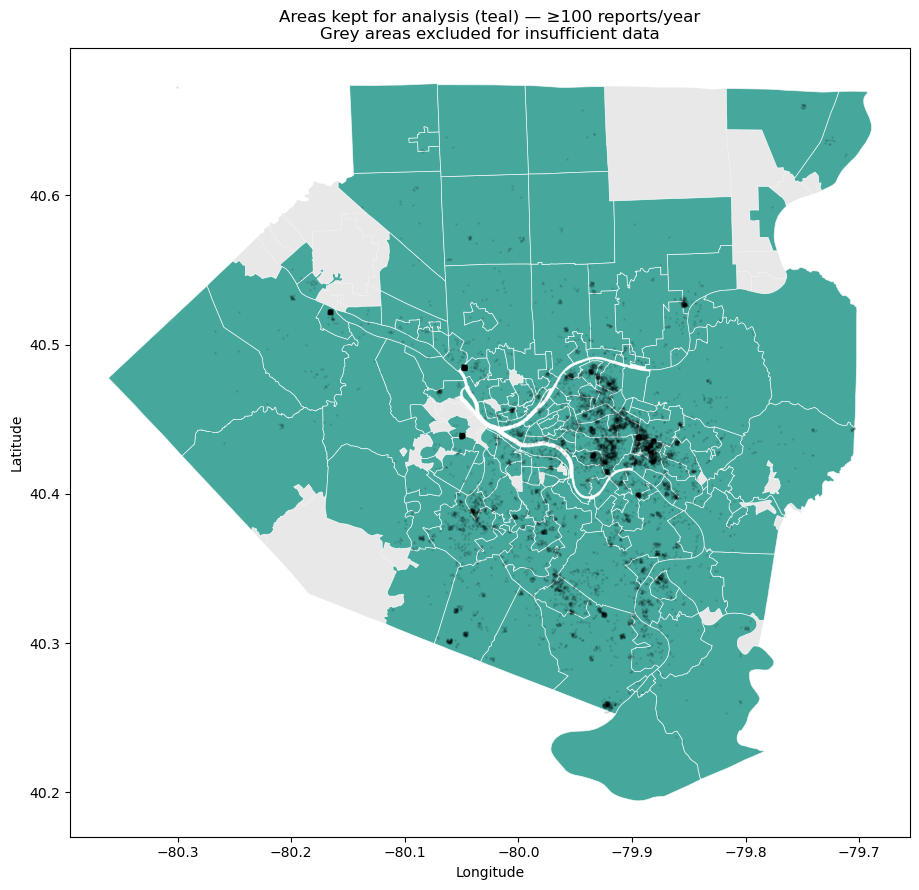

In [20]:
fig, ax = plt.subplots(figsize=(10, 9))

stitched.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3, alpha=0.5)
analysis_areas.plot(ax=ax, color='#2A9D8F', edgecolor='white', linewidth=0.5, alpha=0.85)

ax.scatter(filtered_smell['skewed longitude'], filtered_smell['skewed latitude'],
           s=1, alpha=0.08, color='black')

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Areas kept for analysis (teal) — ≥{MIN_REPORTS_FOR_ANALYSIS} reports/year\n'
             f'Grey areas excluded for insufficient data', fontsize=12)
plt.tight_layout()
plt.savefig('analysis_area_map.png', dpi=130, bbox_inches='tight')
plt.show()



## Step 7 — Combine facility rasters

In [21]:
def combine_facilities(date_str, facility_dirs, nodata=0.0):
    combined = None
    meta = None
    sources = []
    for name, folder in facility_dirs.items():
        fpath = os.path.join(folder, f'{date_str}.tif')
        if not os.path.exists(fpath):
            continue
        with rasterio.open(fpath) as src:
            data = src.read(1).astype(np.float32)
            if meta is None:
                meta = src.meta.copy()
                combined = np.zeros_like(data)
        data[data == nodata] = 0.0
        combined += data
        sources.append(name)
    return combined, meta, sources


all_dates = set()
for name, folder in FACILITY_DIRS.items():
    files = glob.glob(os.path.join(folder, '*.tif'))
    all_dates |= {os.path.basename(f).replace('.tif', '') for f in files}
all_dates = sorted(all_dates)
print(f'Total dates available: {len(all_dates)}')

test_arr, test_meta, test_sources = combine_facilities(all_dates[0], FACILITY_DIRS)
print(f'Test combine: {all_dates[0]}, facilities: {test_sources}, shape: {test_arr.shape}')

Total dates available: 366
Test combine: 20240101, facilities: ['facility_A', 'facility_B', 'facility_C'], shape: (601, 601)


## Step 8 — Build a pixel mask for each area

Same approach as the 3-region notebook: `geometry_mask` figures out which raster pixels fall inside each neighborhood/municipality polygon. Only built for the areas that survived the Step 6 filter.

In [22]:
def build_area_masks(areas_gdf, raster_transform, raster_shape):
    masks = {}
    for _, row in areas_gdf.iterrows():
        mask = geometry_mask(
            [row.geometry],
            out_shape=raster_shape,
            transform=raster_transform,
            invert=True
        )
        masks[row['area_name']] = mask
    return masks


area_masks = build_area_masks(analysis_areas, test_meta['transform'], test_arr.shape)

print(f'Built masks for {len(area_masks)} areas')
print('\nPixel counts (areas with zero pixels likely fall outside the raster domain):')
for name, mask in area_masks.items():
    if mask.sum() == 0:
        print(f'  ⚠ {name}: 0 pixels — outside raster extent, will be dropped')

# Drop any area with zero overlapping pixels (outside the raster domain entirely)
area_masks = {name: mask for name, mask in area_masks.items() if mask.sum() > 0}
print(f'\nAreas with valid raster overlap: {len(area_masks)}')

Built masks for 175 areas

Pixel counts (areas with zero pixels likely fall outside the raster domain):

Areas with valid raster overlap: 175


## Step 9 — Compute each area's pollution sum for every day

In [24]:
records = []

for date_str in all_dates:
    combined, meta, sources = combine_facilities(date_str, FACILITY_DIRS)
    if combined is None:
        continue

    row = {
        'date':     pd.to_datetime(date_str, format='%Y%m%d'),
        'date_str': date_str,
        'facilities': ', '.join(sources),
    }

    for area_name, mask in area_masks.items():
        masked = combined * mask
        row[f'sum_{area_name}'] = float(masked.sum())

    records.append(row)

daily_area = pd.DataFrame(records).sort_values('date').reset_index(drop=True)
print(f'Processed {len(daily_area)} days across {len(area_masks)} areas')

Processed 366 days across 175 areas


## Step 10 — Rank days independently within each area, set thresholds

In [25]:
area_thresholds = {}

for area_name in area_masks.keys():
    sum_col = f'sum_{area_name}'
    threshold = daily_area[sum_col].quantile(1 - TOP_FRACTION)
    area_thresholds[area_name] = threshold
    daily_area[f'notify_{area_name}'] = daily_area[sum_col] >= threshold

print(f'Thresholds computed for {len(area_thresholds)} areas')
print('\nSample:')
for name in list(area_thresholds.keys())[:5]:
    n_notify = daily_area[f'notify_{name}'].sum()
    print(f'  {name}: threshold={area_thresholds[name]:.1f}, notify_days={n_notify}')

Thresholds computed for 175 areas

Sample:
  Point Breeze North: threshold=19.1, notify_days=37
  Squirrel Hill North: threshold=51.3, notify_days=37
  Garfield: threshold=16.8, notify_days=37
  Bedford Dwellings: threshold=4.8, notify_days=37
  Knoxville: threshold=6.8, notify_days=37


## Step 11 — Aggregate smell reports by date and area

In [26]:
smell_with_area['date'] = pd.to_datetime(
    smell_with_area['date & time'].str[:10], format='%m/%d/%Y'
)
smell_with_area['date_str'] = smell_with_area['date'].dt.strftime('%Y%m%d')

smell_filtered_areas = smell_with_area[
    smell_with_area['area_name'].isin(area_masks.keys())
].copy()

smell_daily_by_area = (
    smell_filtered_areas.groupby(['date_str', 'area_name'])
    .agg(n_reports=('smell value', 'count'), mean_smell=('smell value', 'mean'))
    .reset_index()
)

print(f'Daily area smell records: {len(smell_daily_by_area)}')

Daily area smell records: 5934


## Step 12 — Merge and compute FP/FN rates per area

In [27]:
area_names = list(area_masks.keys())

long_rows = []
for _, row in daily_area.iterrows():
    for area_name in area_names:
        long_rows.append({
            'date_str':     row['date_str'],
            'area_name':    area_name,
            'regional_sum': row[f'sum_{area_name}'],
            'notify':       row[f'notify_{area_name}'],
        })
area_long = pd.DataFrame(long_rows)

area_merged = area_long.merge(
    smell_daily_by_area, on=['date_str', 'area_name'], how='left'
)
area_merged['n_reports']  = area_merged['n_reports'].fillna(0).astype(int)
area_merged['mean_smell'] = area_merged['mean_smell'].fillna(0)

print(f'Combined area-day table: {len(area_merged)} rows')

Combined area-day table: 64050 rows


In [28]:
# ── COPYABLE BLOCK: FP/FN rates per area ──────────────────────────────────────

fp_fn_rows = []

for area_name in area_names:
    sub = area_merged[area_merged['area_name'] == area_name].copy()

    smell_high_threshold = sub['n_reports'].quantile(0.75)
    sub['smell_high'] = sub['n_reports'] >= smell_high_threshold

    true_pos  = ((sub['notify'])  & (sub['smell_high'])).sum()
    false_pos = ((sub['notify'])  & (~sub['smell_high'])).sum()
    false_neg = ((~sub['notify']) & (sub['smell_high'])).sum()
    true_neg  = ((~sub['notify']) & (~sub['smell_high'])).sum()

    n_notify_days = sub['notify'].sum()
    n_smell_high  = sub['smell_high'].sum()

    fp_rate = (false_pos / n_notify_days * 100) if n_notify_days > 0 else np.nan
    fn_rate = (false_neg / n_smell_high * 100) if n_smell_high > 0 else np.nan

    fp_fn_rows.append({
        'area_name': area_name,
        'area_type': 'neighborhood' if area_name in neighborhoods['hood'].values else 'municipality',
        'total_reports': sub['n_reports'].sum(),
        'smell_high_threshold': round(smell_high_threshold, 1),
        'false_positive_rate_%': round(fp_rate, 1) if not np.isnan(fp_rate) else None,
        'false_negative_rate_%': round(fn_rate, 1) if not np.isnan(fn_rate) else None,
    })

fp_fn_summary = pd.DataFrame(fp_fn_rows).sort_values('total_reports', ascending=False)
print(fp_fn_summary.to_string(index=False))

# ───────────────────────────────────────────────────────────────────────────

                area_name    area_type  total_reports  smell_high_threshold  false_positive_rate_%  false_negative_rate_%
      Squirrel Hill South neighborhood            750                   2.0                   40.5                   79.6
              WILKINSBURG municipality            490                   2.0                   29.7                   74.3
          JEFFERSON HILLS municipality            481                   2.0                   54.1                   83.3
                 EDGEWOOD municipality            478                   2.0                   54.1                   83.2
                SWISSVALE municipality            425                   1.0                   35.1                   85.4
             WEST MIFFLIN municipality            364                   1.0                   59.5                   90.6
             Point Breeze neighborhood            354                   1.0                   51.4                   86.2
            MOUNT LEBANO

In [30]:
# Check what % of days are actually flagged smell_high per area
for area_name in fp_fn_summary['area_name'].head(10):
    sub = area_merged[area_merged['area_name'] == area_name]
    threshold = sub['n_reports'].quantile(0.75)
    actual_pct_high = (sub['n_reports'] >= threshold).mean() * 100
    print(f'{area_name:<25} threshold={threshold:.1f}  '
          f'actual % of days flagged "high"={actual_pct_high:.1f}%  '
          f'(target was 25%)')

Squirrel Hill South       threshold=2.0  actual % of days flagged "high"=29.5%  (target was 25%)
WILKINSBURG               threshold=2.0  actual % of days flagged "high"=27.6%  (target was 25%)
JEFFERSON HILLS           threshold=2.0  actual % of days flagged "high"=27.9%  (target was 25%)
EDGEWOOD                  threshold=2.0  actual % of days flagged "high"=27.6%  (target was 25%)
SWISSVALE                 threshold=1.0  actual % of days flagged "high"=44.8%  (target was 25%)
WEST MIFFLIN              threshold=1.0  actual % of days flagged "high"=43.4%  (target was 25%)
Point Breeze              threshold=1.0  actual % of days flagged "high"=35.5%  (target was 25%)
MOUNT LEBANON             threshold=1.0  actual % of days flagged "high"=32.0%  (target was 25%)
Brighton Heights          threshold=1.0  actual % of days flagged "high"=55.2%  (target was 25%)
Squirrel Hill North       threshold=1.0  actual % of days flagged "high"=34.2%  (target was 25%)


In [33]:
# Recompute smell_high using exact top 25% by rank, not a value threshold
fp_fn_rows_v2 = []

for area_name in area_names:
    sub = area_merged[area_merged['area_name'] == area_name].copy()
    n_days = len(sub)
    n_top25 = int(np.ceil(n_days * 0.25))

    # Rank days by report count, ties broken by original order (not all bunched at one value)
    sub['report_rank'] = sub['n_reports'].rank(method='first', ascending=False)
    sub['smell_high'] = sub['report_rank'] <= n_top25

    true_pos  = ((sub['notify'])  & (sub['smell_high'])).sum()
    false_pos = ((sub['notify'])  & (~sub['smell_high'])).sum()
    false_neg = ((~sub['notify']) & (sub['smell_high'])).sum()

    n_notify_days = sub['notify'].sum()
    n_smell_high  = sub['smell_high'].sum()

    fp_rate = (false_pos / n_notify_days * 100) if n_notify_days > 0 else np.nan
    fn_rate = (false_neg / n_smell_high * 100) if n_smell_high > 0 else np.nan

    fp_fn_rows_v2.append({
        'area_name': area_name,
        'total_reports': sub['n_reports'].sum(),
        'actual_pct_smell_high': round(n_smell_high / n_days * 100, 1),
        'false_positive_rate_%_v2': round(fp_rate, 1) if not np.isnan(fp_rate) else None,
        'false_negative_rate_%_v2': round(fn_rate, 1) if not np.isnan(fn_rate) else None,
    })

fp_fn_v2 = pd.DataFrame(fp_fn_rows_v2).sort_values('total_reports', ascending=False)

# Drop the duplicate column before merging to avoid a _x/_y collision
fp_fn_v2_for_merge = fp_fn_v2.drop(columns=['total_reports'])

comparison_v2 = fp_fn_summary.merge(fp_fn_v2_for_merge, on='area_name')
print(comparison_v2[['area_name', 'total_reports', 'false_positive_rate_%',
                     'false_positive_rate_%_v2', 'actual_pct_smell_high']].head(15).to_string(index=False))

          area_name  total_reports  false_positive_rate_%  false_positive_rate_%_v2  actual_pct_smell_high
Squirrel Hill South            750                   40.5                      48.6                   25.1
        WILKINSBURG            490                   29.7                      35.1                   25.1
    JEFFERSON HILLS            481                   54.1                      56.8                   25.1
           EDGEWOOD            478                   54.1                      59.5                   25.1
          SWISSVALE            425                   35.1                      54.1                   25.1
       WEST MIFFLIN            364                   59.5                      81.1                   25.1
       Point Breeze            354                   51.4                      56.8                   25.1
      MOUNT LEBANON            319                   43.2                      64.9                   25.1
   Brighton Heights            310   

## Step 13 — Map FP/FN rates spatially, restricted to areas with smell data

Two side-by-side choropleth maps (color-filled polygons) — one for false positive rate, one for false negative rate. Only the analysis areas are shown; the rest of the map is left blank since we don't have enough community data to evaluate those areas.

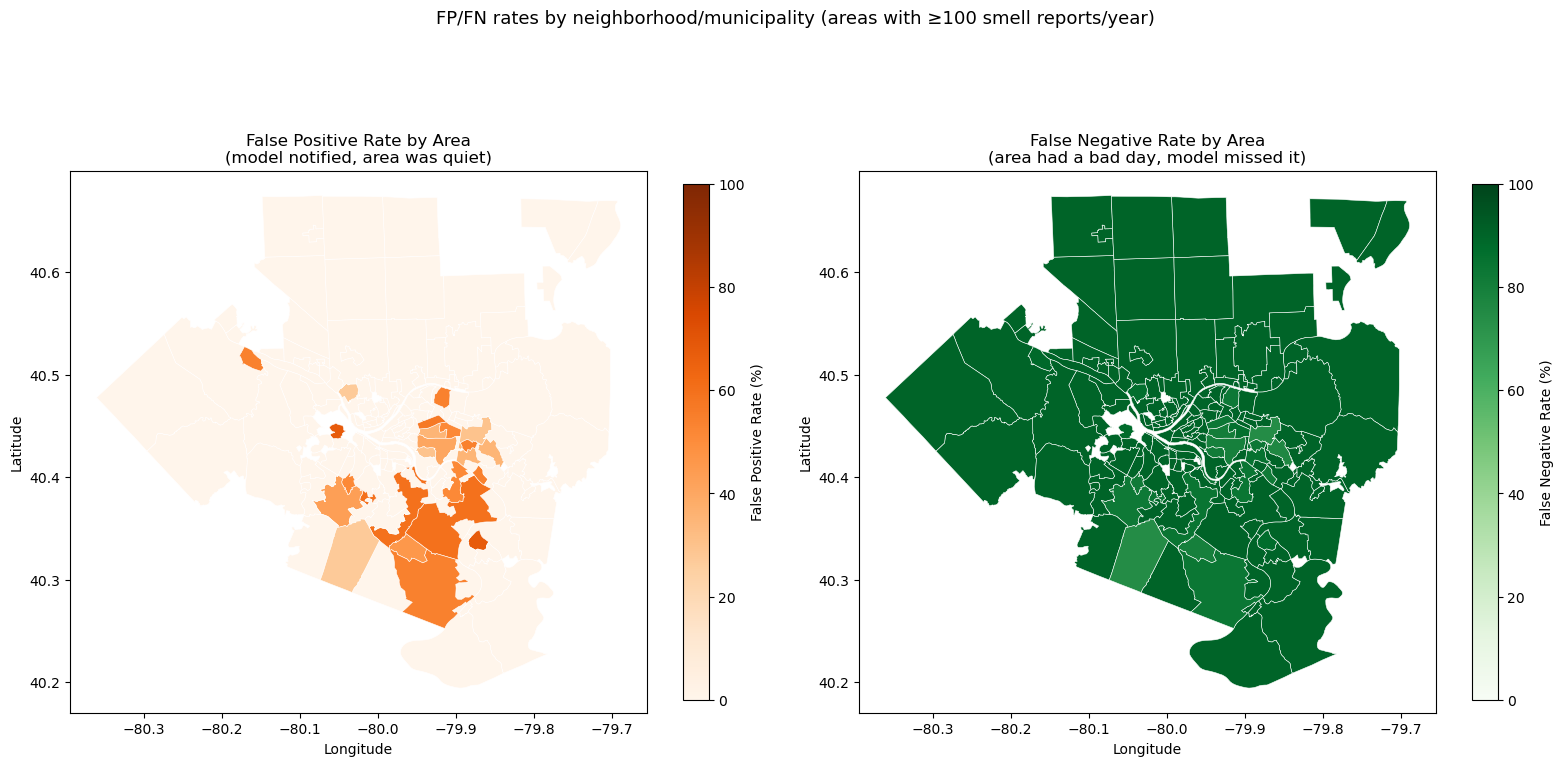

In [34]:
# Merge the FP/FN rates back onto the geographic polygons
map_data = analysis_areas.merge(fp_fn_summary, on='area_name', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

map_data.plot(
    column='false_positive_rate_%', cmap='Oranges', ax=axes[0],
    edgecolor='white', linewidth=0.4, legend=True,
    vmin=0, vmax=100,
    legend_kwds={'label': 'False Positive Rate (%)', 'shrink': 0.7}
)
axes[0].set_title('False Positive Rate by Area\n(model notified, area was quiet)', fontsize=12)
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

map_data.plot(
    column='false_negative_rate_%', cmap='Greens', ax=axes[1],
    edgecolor='white', linewidth=0.4, legend=True,
    vmin=0, vmax=100,
    legend_kwds={'label': 'False Negative Rate (%)', 'shrink': 0.7}
)
axes[1].set_title('False Negative Rate by Area\n(area had a bad day, model missed it)', fontsize=12)
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')

plt.suptitle('FP/FN rates by neighborhood/municipality (areas with ≥{} smell reports/year)'
             .format(MIN_REPORTS_FOR_ANALYSIS), fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('neighborhood_fp_fn_map.png', dpi=150, bbox_inches='tight')
plt.show()

## Save outputs

In [17]:
daily_area.to_csv('daily_area_sums.csv', index=False)
area_merged.to_csv('area_smell_plume_merged.csv', index=False)
fp_fn_summary.to_csv('neighborhood_fp_fn_rates.csv', index=False)

print('Saved:')
print('  daily_area_sums.csv          — one row per day, sum per area')
print('  area_smell_plume_merged.csv  — one row per day x area, plume + smell + notify flags')
print('  neighborhood_fp_fn_rates.csv — FP/FN rate per area')

Saved:
  daily_area_sums.csv          — one row per day, sum per area
  area_smell_plume_merged.csv  — one row per day x area, plume + smell + notify flags
  neighborhood_fp_fn_rates.csv — FP/FN rate per area
